In [22]:
# 统一论文图的风格和尺寸, 方便后续拼接
import os
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm   # 修改 1：新增，用于手动加载 Arial.ttf


# =========================
# 修改 2：只需要改这里
# =========================
ARIAL_TTF_PATH = "/data/jychen/package/Arial/arial.ttf"   # 改成你的 arial.ttf 实际路径
USE_ARIAL_TTF = True                # True = 从 ttf 文件加载 Arial；False = 直接用系统字体名


_PUB_FONT_NAME = None


def load_pub_font():
    """
    手动加载 Arial.ttf，并返回字体在 matplotlib 中识别到的真实名称。
    这样可以避免系统装了 Arial 但 matplotlib 仍然找不到的问题。
    """
    global _PUB_FONT_NAME

    if _PUB_FONT_NAME is not None:
        return _PUB_FONT_NAME

    if USE_ARIAL_TTF:
        if not os.path.exists(ARIAL_TTF_PATH):
            raise FileNotFoundError(f"找不到 Arial 字体文件: {ARIAL_TTF_PATH}")

        fm.fontManager.addfont(ARIAL_TTF_PATH)
        _PUB_FONT_NAME = fm.FontProperties(fname=ARIAL_TTF_PATH).get_name()
    else:
        _PUB_FONT_NAME = "Arial"

    print(f"Using font: {_PUB_FONT_NAME}")
    return _PUB_FONT_NAME


def mm_to_inch(mm):
    return mm / 25.4


FIG_SIZE = {
    "single": 120,
    "double": 180,
}


FIG_PRESETS = {
    "single_small":  ("single", 60),
    "single_medium": ("single", 75),
    "double_short":  ("double", 70),
    "double_medium": ("double", 100),
    "double_large":  ("double", 140),
}


_SHARED_FONT_SIZES = {
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
}


def set_pub_style():
    pub_font = load_pub_font()   # 修改 3：每次设置风格前，先确保 Arial.ttf 已经加载

    base = {
        # 修改 4：不再直接写死 "Arial"，而是使用 ttf 文件真实识别到的字体名
        "font.family": pub_font,
        "font.sans-serif": [pub_font, "Arial", "Helvetica", "Liberation Sans", "DejaVu Sans"],

        "font.weight": "normal",
        "axes.labelweight": "normal",
        "axes.titleweight": "normal",

        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "svg.fonttype": "none",

        # 稍粗一些的论文图风格
        "axes.linewidth": 1.5,
        "xtick.major.width": 1.4,
        "ytick.major.width": 1.4,
        "xtick.minor.width": 1.1,
        "ytick.minor.width": 1.1,
        "xtick.major.size": 4.5,
        "ytick.major.size": 4.5,
        "xtick.minor.size": 2.8,
        "ytick.minor.size": 2.8,
        "xtick.direction": "in",
        "ytick.direction": "in",

        "lines.linewidth": 1.7,
        "patch.linewidth": 1.3,

        "legend.frameon": False,
        "legend.handlelength": 1.5,
        "legend.handletextpad": 0.4,

        "axes.unicode_minus": False,
        "axes.spines.top": True,
        "axes.spines.right": True,

        "savefig.dpi": 600,
        "figure.dpi": 120,
    }

    base.update(_SHARED_FONT_SIZES)
    mpl.rcParams.update(base)


def new_figure(mode="single", height_mm=65):
    set_pub_style()
    width_mm = FIG_SIZE[mode]
    fig, ax = plt.subplots(
        figsize=(mm_to_inch(width_mm), mm_to_inch(height_mm))
    )
    return fig, ax


def new_subplots(nrows, ncols, preset="double_medium", **kwargs):
    set_pub_style()
    mode, height_mm = FIG_PRESETS[preset]
    width_mm = FIG_SIZE[mode]

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(mm_to_inch(width_mm), mm_to_inch(height_mm)),
        **kwargs
    )
    return fig, axes


def savefig_pub(fig, filename, dpi=600, tight=False):
    if tight:
        fig.savefig(filename, dpi=dpi, bbox_inches="tight", pad_inches=0.02)
    else:
        fig.savefig(filename, dpi=dpi)


# 应用统一风格模板
set_pub_style()

Using font: Arial


In [23]:
# contact map 专用 helper。cell 1 只负责统一风格，这里补充 contact map 的公共函数。
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm, SymLogNorm
from matplotlib.ticker import FuncFormatter
from mpl_toolkits.axes_grid1 import make_axes_locatable

FIG_PRESETS.update({
    "single_contactmap": ("single", 83),
    "single_diffmap": ("single", 99),
})

CONTACTMAP_TICKS = [1, 20, 40, 60, 80, 100, 120, 140]
AVERAGE_MAP_ADJUST = {
    "bottom": 0.16,
    "left": 0.16,
    "right": 0.88,
    "top": 0.90,
}
DIFF_MAP_ADJUST = {
    "bottom": 0.28,
    "left": 0.32,
    "right": 0.84,
    "top": 0.90,
}
RESIDUE_SEGMENTS = [
    (-0.5, 59.5, "blue", "N-ter"),
    (59.5, 94.5, "green", "NAC"),
    (94.5, 139.5, "red", "C-Ter"),
]


def new_figure_from_preset(preset="single_medium", **kwargs):
    mode, height_mm = FIG_PRESETS[preset]
    return new_figure(mode=mode, height_mm=height_mm, **kwargs)


def load_and_average(file_list):
    matrices = [np.load(path) for path in file_list]
    avg_matrix = np.nanmean(np.stack(matrices), axis=0)
    avg_matrix[avg_matrix == 0] = np.nan
    return avg_matrix


def calculate_difference_contact_map(group_a_files, group_b_files):
    avg_a = load_and_average(group_a_files)
    avg_b = load_and_average(group_b_files)
    diff_matrix = avg_a - avg_b
    diff_matrix[diff_matrix == 0] = np.nan
    return diff_matrix


def add_colorbar(ax, im, label, tick_labelsize=8.5, size="4.5%", pad=0.08):
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size=size, pad=pad)
    cbar = ax.figure.colorbar(im, cax=cax)
    cbar.set_label(label, fontsize=mpl.rcParams["axes.labelsize"])
    cbar.ax.tick_params(
        labelsize=tick_labelsize,
        width=1.0,
        length=3.5,
        direction="out",
    )
    cbar.outline.set_linewidth(1.1)
    for spine in cax.spines.values():
        spine.set_linewidth(1.1)
    return cbar, cax


def apply_contactmap_axes(ax, title, xlabel="Residue index", ylabel="Residue index"):
    ax.invert_yaxis()
    ax.set_title(title, pad=6)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    tick_positions = [tick - 1 for tick in CONTACTMAP_TICKS]
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(CONTACTMAP_TICKS)
    ax.set_yticks(tick_positions)
    ax.set_yticklabels(CONTACTMAP_TICKS)
    ax.tick_params(axis="x", pad=6)
    ax.tick_params(axis="y", pad=6)
    ax.minorticks_off()

    for spine in ax.spines.values():
        spine.set_linewidth(1.5)


def add_residue_segments(ax, segments=RESIDUE_SEGMENTS):
    trans_x = ax.get_xaxis_transform()
    y_strip_max = -0.18
    y_strip_min = -0.26
    y_label_pos = (y_strip_min + y_strip_max) / 2

    for x_start, x_end, color, label in segments:
        ax.axvspan(
            x_start,
            x_end,
            ymin=y_strip_min,
            ymax=y_strip_max,
            facecolor=color,
            edgecolor="black",
            linewidth=0.9,
            transform=trans_x,
            clip_on=False,
            zorder=3,
        )
        ax.text(
            (x_start + x_end) / 2,
            y_label_pos,
            label,
            transform=trans_x,
            ha="center",
            va="center",
            fontsize=8.5,
            color="white",
            clip_on=False,
            fontweight="bold",
        )

    trans_y = ax.get_yaxis_transform()
    x_strip_max = -0.20
    x_strip_min = -0.28
    x_label_pos = (x_strip_min + x_strip_max) / 2

    for y_start, y_end, color, label in segments:
        ax.axhspan(
            y_start,
            y_end,
            xmin=x_strip_min,
            xmax=x_strip_max,
            facecolor=color,
            edgecolor="black",
            linewidth=0.9,
            transform=trans_y,
            clip_on=False,
            zorder=3,
        )
        ax.text(
            x_label_pos,
            (y_start + y_end) / 2,
            label,
            transform=trans_y,
            ha="center",
            va="center",
            fontsize=8.5,
            color="white",
            rotation=90,
            clip_on=False,
            fontweight="bold",
        )


def add_nac_boundary_lines(
    ax,
    segments=RESIDUE_SEGMENTS,
    color="black",
    linewidth=1.0,
    linestyle="--",
):
    nac_segment = next(segment for segment in segments if segment[3] == "NAC")
    for boundary in (nac_segment[0], nac_segment[1]):
        ax.axvline(
            boundary,
            color=color,
            linewidth=linewidth,
            linestyle=linestyle,
            zorder=4,
        )
        ax.axhline(
            boundary,
            color=color,
            linewidth=linewidth,
            linestyle=linestyle,
            zorder=4,
        )


def format_symlog_colorbar(cbar, vmax, linthresh, tick_labelsize=8.2):
    exp_max = int(np.floor(np.log10(vmax)))
    tick_hi = 10.0 ** exp_max
    tick_mid = 10.0 ** (exp_max - 1)
    pos_ticks = [tick_hi] if tick_mid <= linthresh * 1.5 else [tick_mid, tick_hi]
    ticks = np.array(sorted(set([0.0] + pos_ticks + [-tick for tick in pos_ticks])))
    cbar.set_ticks(ticks)

    def _fmt_tick(value, _):
        if np.isclose(value, 0.0):
            return "0"
        exponent = int(np.round(np.log10(abs(value))))
        sign = "-" if value < 0 else ""
        return rf"{sign}$10^{{{exponent}}}$"

    cbar.ax.yaxis.set_major_formatter(FuncFormatter(_fmt_tick))
    cbar.ax.minorticks_off()
    cbar.ax.tick_params(
        labelsize=tick_labelsize,
        width=1.0,
        length=3.5,
        direction="out",
        pad=2,
    )


def plot_average_contact_map(
    file_list,
    title,
    preset="single_contactmap",
    vmin=1e-5,
    vmax=1e-2,
    cmap="magma",
    colorbar_label="Contact frequency",
    xlabel="Residue index",
    ylabel="Residue index",
    adjust=None,
    save_name=None,
):
    contact_avg = load_and_average(file_list)
    fig, ax = new_figure_from_preset(preset)
    im = ax.imshow(contact_avg, cmap=cmap, norm=LogNorm(vmin=vmin, vmax=vmax))
    cbar, _ = add_colorbar(ax, im, colorbar_label)
    apply_contactmap_axes(ax, title, xlabel=xlabel, ylabel=ylabel)

    fig_adjust = dict(AVERAGE_MAP_ADJUST)
    if adjust:
        fig_adjust.update(adjust)
    fig.subplots_adjust(**fig_adjust)

    if save_name:
        savefig_pub(fig, save_name)

    return fig, ax, contact_avg, cbar


def plot_difference_contact_map(
    group_a_files,
    group_b_files,
    title,
    positive_message=None,
    negative_message=None,
    preset="single_diffmap",
    cbar_absmax=None,
    cmap="coolwarm",
    colorbar_label="Contact frequency difference",
    xlabel="",
    ylabel="",
    show_colorbar=True,
    show_segments=True,
    show_nac_boundaries=True,
    nac_boundary_color="black",
    nac_boundary_linewidth=1.0,
    nac_boundary_linestyle="--",
    adjust=None,
    save_name=None,
):
    avg_a = load_and_average(group_a_files)
    avg_b = load_and_average(group_b_files)
    diff_matrix = avg_a - avg_b
    diff_matrix[diff_matrix == 0] = np.nan

    abs_vals = np.abs(diff_matrix[np.isfinite(diff_matrix)])
    if abs_vals.size == 0:
        raise ValueError("Difference matrix contains no finite values.")

    vmax = float(cbar_absmax) if cbar_absmax is not None else float(np.nanmax(abs_vals))
    vmin = -vmax
    linthresh = max(vmax * 1e-2, float(np.nanpercentile(abs_vals, 5)))

    fig, ax = new_figure_from_preset(preset)
    norm = SymLogNorm(
        linthresh=linthresh,
        linscale=1.0,
        vmin=vmin,
        vmax=vmax,
        base=10,
    )
    im = ax.imshow(diff_matrix, cmap=cmap, norm=norm)
    cbar, _ = add_colorbar(ax, im, colorbar_label, tick_labelsize=10)
    format_symlog_colorbar(cbar, vmax, linthresh, tick_labelsize=10)
    apply_contactmap_axes(ax, title, xlabel=xlabel, ylabel=ylabel)

    if show_segments:
        add_residue_segments(ax)
    if show_nac_boundaries:
        add_nac_boundary_lines(
            ax,
            color=nac_boundary_color,
            linewidth=nac_boundary_linewidth,
            linestyle=nac_boundary_linestyle,
        )

    fig_adjust = dict(DIFF_MAP_ADJUST)
    if adjust:
        fig_adjust.update(adjust)
    fig.subplots_adjust(**fig_adjust)

    if save_name:
        savefig_pub(fig, save_name)

    total_diff = np.nansum(diff_matrix)
    if positive_message and total_diff > 0:
        print(positive_message)
    elif negative_message and total_diff < 0:
        print(negative_message)

    return fig, ax, diff_matrix, total_diff, cbar


def plot_split_difference_contact_map(
    first_group_a_files,
    first_group_b_files,
    second_group_a_files,
    second_group_b_files,
    title,
    preset="single_diffmap",
    cbar_absmax=None,
    cmap="coolwarm",
    colorbar_label="Contact frequency difference",
    xlabel="",
    ylabel="",
    show_segments=True,
    show_nac_boundaries=True,
    nac_boundary_color="black",
    nac_boundary_linewidth=1.0,
    nac_boundary_linestyle="--",
    upper_left_label=None,
    lower_right_label=None,
    label_fontsize=6.8,
    adjust=None,
    save_name=None,
):
    first_diff = calculate_difference_contact_map(first_group_a_files, first_group_b_files)
    second_diff = calculate_difference_contact_map(second_group_a_files, second_group_b_files)

    if first_diff.shape != second_diff.shape:
        raise ValueError(
            "The two difference matrices must have the same shape: "
            f"{first_diff.shape} != {second_diff.shape}"
        )

    finite_groups = [
        np.abs(matrix[np.isfinite(matrix)])
        for matrix in (first_diff, second_diff)
    ]
    finite_groups = [values for values in finite_groups if values.size]
    if not finite_groups:
        raise ValueError("Difference matrices contain no finite values.")

    abs_vals = np.concatenate(finite_groups)
    vmax = float(cbar_absmax) if cbar_absmax is not None else float(np.nanmax(abs_vals))
    vmin = -vmax
    linthresh = max(vmax * 1e-2, float(np.nanpercentile(abs_vals, 5)))

    rows, cols = np.indices(first_diff.shape)
    # apply_contactmap_axes() flips the y-axis, so rows >= cols is the displayed upper-left half.
    upper_left_mask = rows >= cols
    lower_right_mask = ~upper_left_mask

    combined_diff = np.full(first_diff.shape, np.nan, dtype=float)
    combined_diff[upper_left_mask] = first_diff[upper_left_mask]
    combined_diff[lower_right_mask] = second_diff[lower_right_mask]

    fig, ax = new_figure_from_preset(preset)
    norm = SymLogNorm(
        linthresh=linthresh,
        linscale=1.0,
        vmin=vmin,
        vmax=vmax,
        base=10,
    )
    im = ax.imshow(combined_diff, cmap=cmap, norm=norm)
    cbar = None
    if show_colorbar:
        cbar, _ = add_colorbar(ax, im, colorbar_label, tick_labelsize=10)
        format_symlog_colorbar(cbar, vmax, linthresh, tick_labelsize=10)
    apply_contactmap_axes(ax, title, xlabel=xlabel, ylabel=ylabel)

    if show_segments:
        add_residue_segments(ax)
    if show_nac_boundaries:
        add_nac_boundary_lines(
            ax,
            color=nac_boundary_color,
            linewidth=nac_boundary_linewidth,
            linestyle=nac_boundary_linestyle,
        )

    nrows, ncols = combined_diff.shape
    label_box = dict(
        boxstyle="square,pad=0.18",
        facecolor="white",
        edgecolor="none",
        alpha=0.78,
    )
    if upper_left_label:
        ax.text(
            4,
            nrows - 6,
            upper_left_label,
            ha="left",
            va="top",
            fontsize=label_fontsize,
            color="black",
            bbox=label_box,
            zorder=5,
        )
    if lower_right_label:
        ax.text(
            ncols - 4,
            6,
            lower_right_label,
            ha="right",
            va="bottom",
            fontsize=label_fontsize,
            color="black",
            bbox=label_box,
            zorder=5,
        )

    fig_adjust = dict(DIFF_MAP_ADJUST)
    if adjust:
        fig_adjust.update(adjust)
    fig.subplots_adjust(**fig_adjust)

    if save_name:
        savefig_pub(fig, save_name)

    total_diffs = (np.nansum(first_diff), np.nansum(second_diff))
    return fig, ax, combined_diff, first_diff, second_diff, total_diffs, cbar



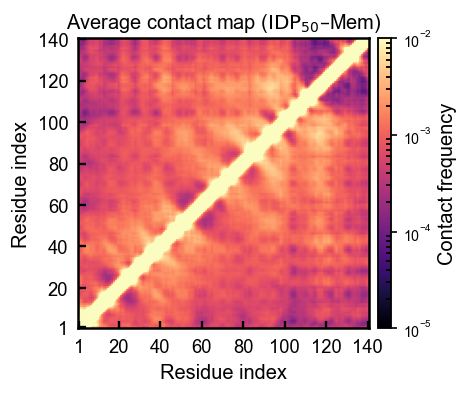

In [24]:
# 只改这里：统一模板下每张图只需要调整文件、标题和尺寸预设
FIG_PRESET = "single_contactmap"
FILES = ['01.npy', '02.npy', '03.npy']
TITLE = r'Average contact map ($\mathrm{IDP}_{50}$–Mem)'
VMIN = 1e-5
VMAX = 1e-2
SAVE_NAME = 'contactmap_avg_idp50_mem_intra.png'

fig, ax, contact_avg, cbar = plot_average_contact_map(
    FILES,
    TITLE,
    preset=FIG_PRESET,
    vmin=VMIN,
    vmax=VMAX,
    save_name=SAVE_NAME,
)
plt.show()


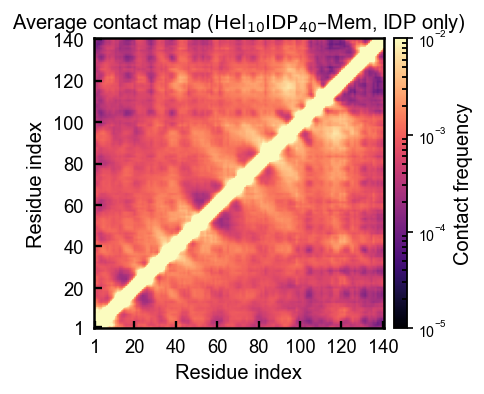

In [25]:
# 只改这里：统一模板下每张图只需要调整文件、标题和尺寸预设
FIG_PRESET = "single_contactmap"
FILES = ['71.npy', '72.npy', '73.npy']
TITLE = r'Average contact map ($\mathrm{Hel}_{10}\mathrm{IDP}_{40}$–Mem, IDP only)'
VMIN = 1e-5
VMAX = 1e-2
SAVE_NAME = 'contactmap_avg_hel10_idp40_mem_idp_only_intra.png'

fig, ax, contact_avg, cbar = plot_average_contact_map(
    FILES,
    TITLE,
    preset=FIG_PRESET,
    vmin=VMIN,
    vmax=VMAX,
    save_name=SAVE_NAME,
)
plt.show()


sol 结构的总接触频率更高。


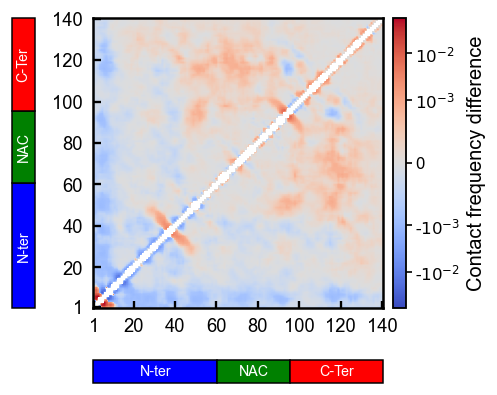

In [26]:
# 只改这里：比较的两组文件、标题和色标范围
FIG_PRESET = "single_diffmap"
GROUP_A_FILES = ['/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Analysis/contactmap/mulchain_mem/intra/01.npy',
 '/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Analysis/contactmap/mulchain_mem/intra/02.npy',
 '/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Analysis/contactmap/mulchain_mem/intra/03.npy']
GROUP_B_FILES = ['/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Analysis/contactmap/mulchain_sol/intra/01.npy',
 '/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Analysis/contactmap/mulchain_sol/intra/02.npy',
 '/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Analysis/contactmap/mulchain_sol/intra/03.npy']
TITLE = ''
CBAR_ABSMAX = None
POSITIVE_MESSAGE = 'mem 结构的总接触频率更高。'
NEGATIVE_MESSAGE = 'sol 结构的总接触频率更高。'
SAVE_NAME = 'contactmap_diff_idp50_mem_minus_idp50_sol_intra.png'

fig, ax, diff_matrix, total_diff, cbar = plot_difference_contact_map(
    GROUP_A_FILES,
    GROUP_B_FILES,
    TITLE,
    positive_message=POSITIVE_MESSAGE,
    negative_message=NEGATIVE_MESSAGE,
    preset=FIG_PRESET,
    cbar_absmax=CBAR_ABSMAX,
    save_name=SAVE_NAME,
)
plt.show()


sol 结构的总接触频率更高。


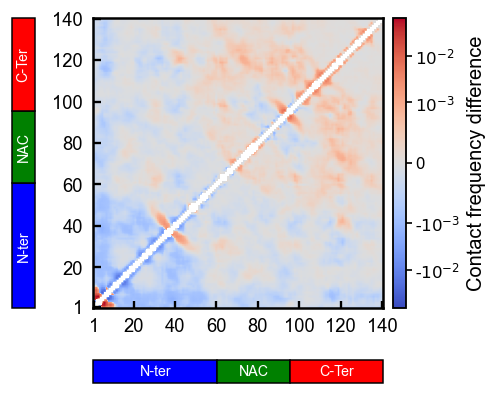

In [27]:
# 只改这里：比较的两组文件、标题和色标范围
FIG_PRESET = "single_diffmap"
GROUP_A_FILES = ['/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Analysis/contactmap/mulchain_mem/intra/71.npy',
 '/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Analysis/contactmap/mulchain_mem/intra/72.npy',
 '/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Analysis/contactmap/mulchain_mem/intra/73.npy']
GROUP_B_FILES = ['/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Analysis/contactmap/mulchain_sol/intra/01.npy',
 '/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Analysis/contactmap/mulchain_sol/intra/02.npy',
 '/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Analysis/contactmap/mulchain_sol/intra/03.npy']
TITLE = ''
CBAR_ABSMAX = None
POSITIVE_MESSAGE = 'mem 结构的总接触频率更高。'
NEGATIVE_MESSAGE = 'sol 结构的总接触频率更高。'
SAVE_NAME = 'contactmap_diff_hel10_idp40_mem_idp_only_minus_idp50_sol_intra.png'

fig, ax, diff_matrix, total_diff, cbar = plot_difference_contact_map(
    GROUP_A_FILES,
    GROUP_B_FILES,
    TITLE,
    positive_message=POSITIVE_MESSAGE,
    negative_message=NEGATIVE_MESSAGE,
    preset=FIG_PRESET,
    cbar_absmax=CBAR_ABSMAX,
    save_name=SAVE_NAME,
)
plt.show()


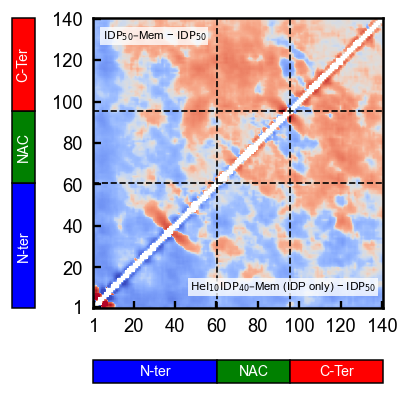

In [28]:
# 只改这里：合并最后两个差值矩阵，左上角是第一组，右下角是第二组
FIG_PRESET = "single_diffmap"
FIRST_GROUP_A_FILES = ['/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Analysis/contactmap/mulchain_mem/intra/01.npy',
 '/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Analysis/contactmap/mulchain_mem/intra/02.npy',
 '/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Analysis/contactmap/mulchain_mem/intra/03.npy']
FIRST_GROUP_B_FILES = ['/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Analysis/contactmap/mulchain_sol/intra/01.npy',
 '/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Analysis/contactmap/mulchain_sol/intra/02.npy',
 '/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Analysis/contactmap/mulchain_sol/intra/03.npy']
SECOND_GROUP_A_FILES = ['/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Analysis/contactmap/mulchain_mem/intra/71.npy',
 '/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Analysis/contactmap/mulchain_mem/intra/72.npy',
 '/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Analysis/contactmap/mulchain_mem/intra/73.npy']
SECOND_GROUP_B_FILES = FIRST_GROUP_B_FILES
TITLE = ''
CBAR_ABSMAX = 0.01
UPPER_LEFT_LABEL = r"$\mathrm{IDP}_{50}$–Mem − $\mathrm{IDP}_{50}$"
LOWER_RIGHT_LABEL = r"$\mathrm{Hel}_{10}\mathrm{IDP}_{40}$–Mem (IDP only) − $\mathrm{IDP}_{50}$"
LABEL_FONT_SIZE = 6.8
SHOW_NAC_BOUNDARIES = True
SHOW_COLORBAR = False
show_colorbar = SHOW_COLORBAR
SAVE_NAME = 'contactmap_diff_combined_mem_minus_sol_intra.png'

fig, ax, combined_diff_matrix, first_diff_matrix, second_diff_matrix, total_diffs, cbar = plot_split_difference_contact_map(
    FIRST_GROUP_A_FILES,
    FIRST_GROUP_B_FILES,
    SECOND_GROUP_A_FILES,
    SECOND_GROUP_B_FILES,
    TITLE,
    preset=FIG_PRESET,
    cbar_absmax=CBAR_ABSMAX,
    upper_left_label=UPPER_LEFT_LABEL,
    lower_right_label=LOWER_RIGHT_LABEL,
    label_fontsize=LABEL_FONT_SIZE,
    show_nac_boundaries=SHOW_NAC_BOUNDARIES,
    save_name=SAVE_NAME if SHOW_COLORBAR else None,
)

if not SHOW_COLORBAR:
    if cbar is not None:
        cbar.remove()
        cbar = None
    if SAVE_NAME:
        savefig_pub(fig, SAVE_NAME)

plt.show()
